In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from collections import Counter
import random

In [2]:
CLASSES = ['NORMAL', 'PNEUMONIA']
CSV_PATH= './dataset.csv'

In [3]:
df= pd.read_csv(CSV_PATH)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5824 entries, 0 to 5823
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   images  5824 non-null   object
 1   labels  5824 non-null   object
dtypes: object(2)
memory usage: 91.1+ KB


In [ ]:
df.head()

### Visualization 1: Class imbalance bar plot

In [35]:
counts= df['labels'].value_counts().values
labels= df['labels'].value_counts().keys()

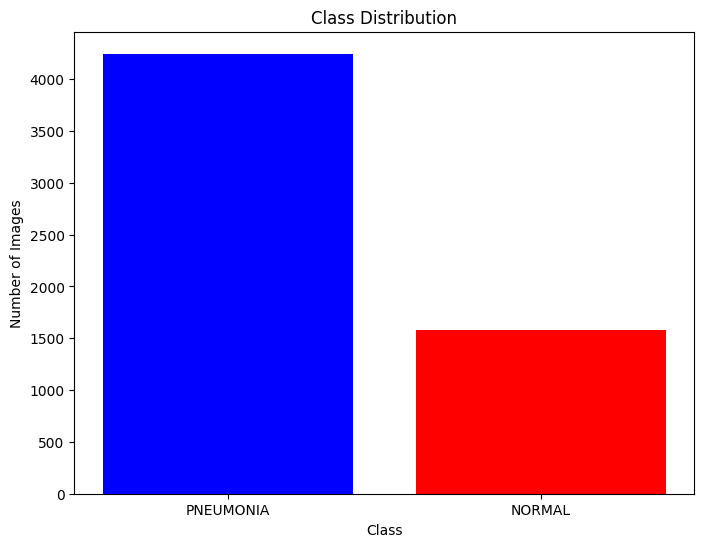

In [37]:
plt.figure(figsize=(8,6))
plt.bar(labels, counts, color=['blue', 'red'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.show()

### Visualization 2: Pie chart

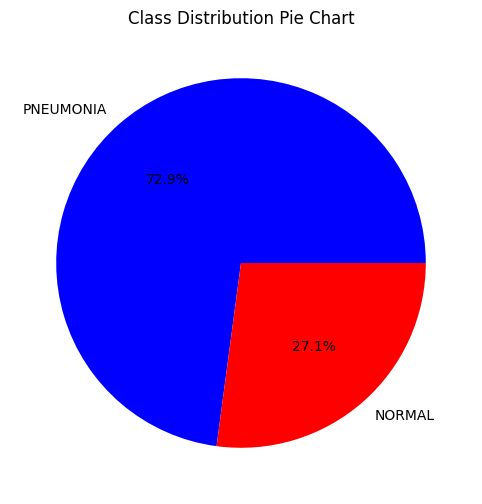

In [38]:
plt.figure(figsize=(8,6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=['blue', 'red'])
plt.title('Class Distribution Pie Chart')
plt.show()

### Visualization 3: Histogram of mean pixel intensities

In [34]:
# Analyze pixel intensities and sizes
mean_intensities = []
sizes = []
for path in df['images']:  # Sample 500 images for speed
    img = np.array(Image.open(path).convert('L'))  # Grayscale
    mean_intensities.append(img.mean())
    sizes.append(img.shape)

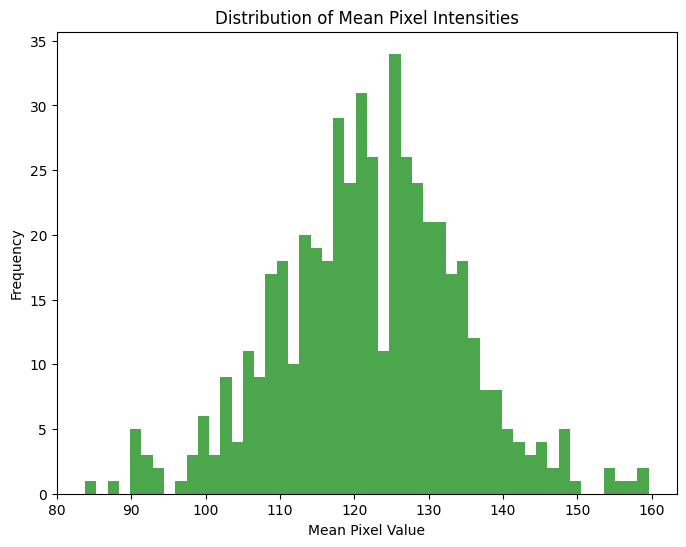

In [22]:
plt.figure(figsize=(8,6))
plt.hist(mean_intensities, bins=50, alpha=0.7, color='green')
plt.title('Distribution of Mean Pixel Intensities')
plt.xlabel('Mean Pixel Value')
plt.ylabel('Frequency')
plt.show()

### Visualization 4: Scatter plot of image sizes

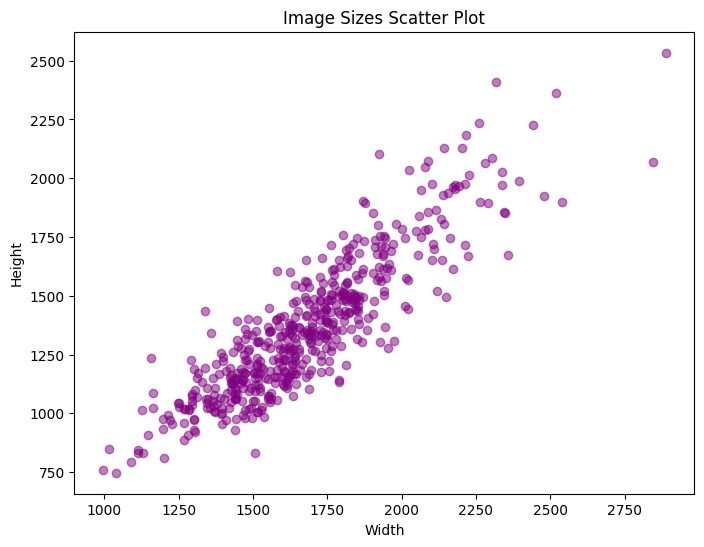

In [23]:
widths = [s[1] for s in sizes]
heights = [s[0] for s in sizes]
plt.figure(figsize=(8,6))
plt.scatter(widths, heights, alpha=0.5, color='purple')
plt.title('Image Sizes Scatter Plot')
plt.xlabel('Width')
plt.ylabel('Height')
plt.show()

### Visualization 5: Box plot of intensities by class

In [ ]:
intensities_by_class= [[], []]
for path, label in zip(df['images'], df['labels']):
    img= np.array(Image.open(path).convert('L'))
    intensities_by_class[0 if label=='NORMAL' else 1].append(img.mean()) #TODO: optimize this

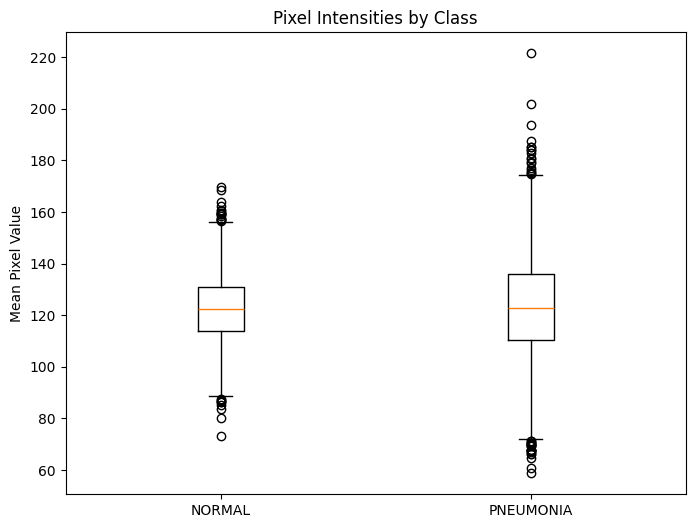

In [ ]:
plt.figure(figsize=(8,6)) #TODO: better visuals
plt.boxplot(intensities_by_class, tick_labels=CLASSES)
plt.title('Pixel Intensities by Class')
plt.ylabel('Mean Pixel Value')
plt.show()

### Visualization 6: Sample images

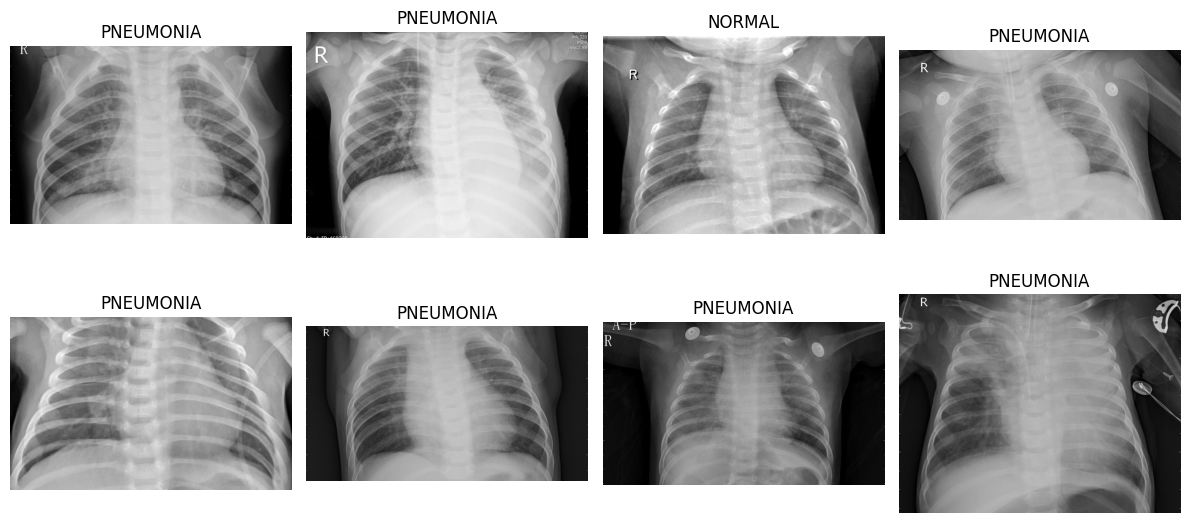

In [31]:
fig, axes = plt.subplots(2, 4, figsize=(12,6))
for i in range(8):
    idx = random.randint(0, len(df['images'])-1)
    img = Image.open(df['images'].iloc[idx])
    axes[i//4, i%4].imshow(img, cmap='gray')
    axes[i//4, i%4].set_title(df['labels'].iloc[idx])
    axes[i//4, i%4].axis('off')
plt.tight_layout()
plt.show()

### Visualization 7: Size distribution

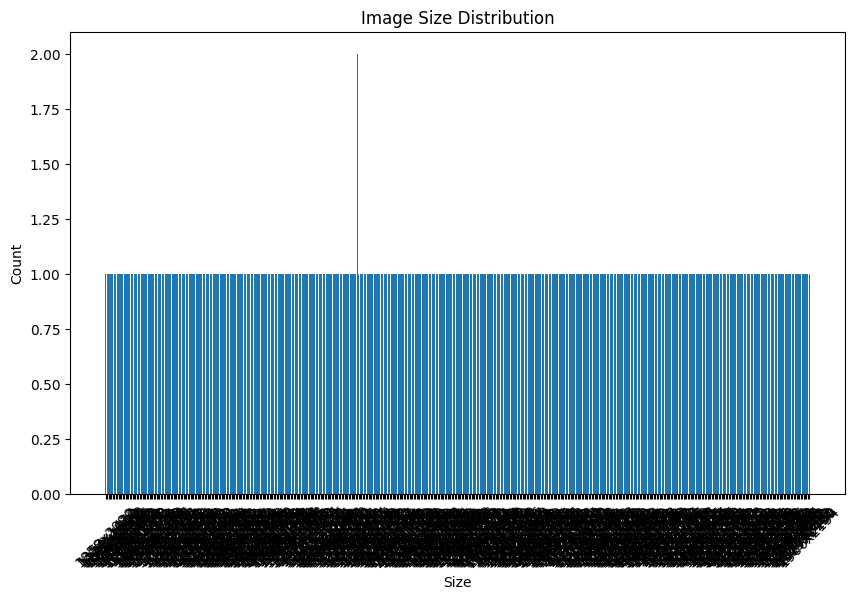

In [ ]:
unique_sizes = Counter(sizes)	#TODO: rewrite this mess
sizes_list = list(unique_sizes.keys())
counts = list(unique_sizes.values())
plt.figure(figsize=(10,6))
plt.bar(range(len(sizes_list)), counts, tick_label=[f'{s[0]}x{s[1]}' for s in sizes_list])
plt.title('Image Size Distribution')
plt.xlabel('Size')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### Visualization 8: Cumulative distribution of intensities

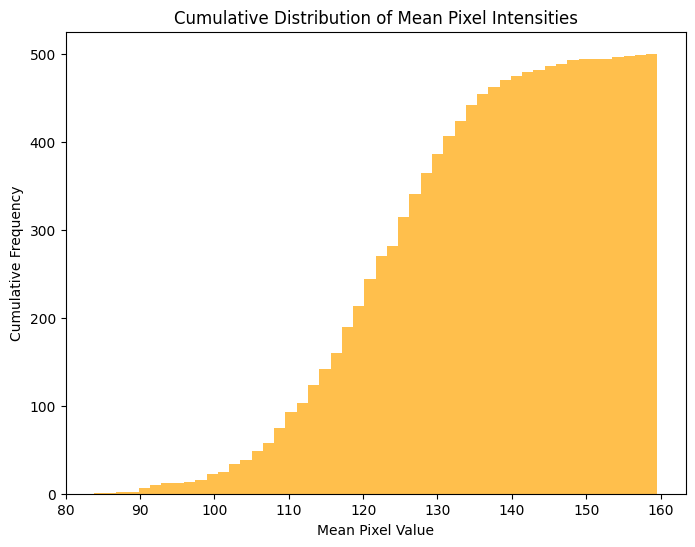

In [33]:
plt.figure(figsize=(8,6))
plt.hist(mean_intensities, bins=50, cumulative=True, alpha=0.7, color='orange')
plt.title('Cumulative Distribution of Mean Pixel Intensities')
plt.xlabel('Mean Pixel Value')
plt.ylabel('Cumulative Frequency')
plt.show()

In [ ]:
#TODO: maybe add more diverse visualizations